In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ==================================================
# TEMA GLOBAL BASADO EN PALETA EQUINOR
# ==================================================

equinor_palette = {
    "energy_red": "#EB0037",
    "white": "#FFFFFF",
    "mist_blue": "#D5EAF4",
    "heritage_red": "#990024",
    "slate_grey": "#6F6F6F",
    "pickled_bluewood": "#253747"
}

# Paleta principal para gráficos
PALETA = [
    equinor_palette["energy_red"],
    equinor_palette["mist_blue"],
    equinor_palette["slate_grey"],
    equinor_palette["heritage_red"],
    equinor_palette["pickled_bluewood"]
]

# Tema seaborn global
sns.set_theme(
    style="whitegrid",
    context="talk",
    palette=PALETA
)

# Ajustes matplotlib globales
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["figure.facecolor"] = equinor_palette["white"]
plt.rcParams["axes.facecolor"] = equinor_palette["white"]

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlecolor"] = equinor_palette["pickled_bluewood"]

plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelcolor"] = equinor_palette["pickled_bluewood"]

plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.color"] = equinor_palette["slate_grey"]
plt.rcParams["ytick.color"] = equinor_palette["slate_grey"]

plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.color"] = equinor_palette["slate_grey"]

plt.rcParams["legend.frameon"] = False
plt.rcParams["text.color"] = equinor_palette["pickled_bluewood"]

plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = equinor_palette["slate_grey"]

# Heatmap Equinor
CMAP_HEATMAP = LinearSegmentedColormap.from_list(
    "equinor_heatmap",
    [
        equinor_palette["mist_blue"],
        equinor_palette["white"],
        equinor_palette["energy_red"],
        equinor_palette["heritage_red"]
    ]
)

## 1. Carga y Comprensión de Datos
Se carga el dataset `global_supply_chain_risk_2026.csv` que contiene registros de envíos internacionales con variables operativas, climáticas y geopolíticas. El objetivo es comprender su estructura antes de cualquier transformación.

In [4]:
df=pd.read_csv(r"C:\Ana_CDPY\Especializacion\S13.01\global_supply_chain_risk_2026.csv")
df

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1


In [5]:
# Asegurar formato datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extraer años únicos
years = df['Date'].dt.year.dropna().unique()

print("Años en el dataset:", sorted(years))

# Rango (mínimo y máximo)
print("Desde:", df['Date'].min())
print("Hasta:", df['Date'].max())

Años en el dataset: [np.int32(2024), np.int32(2025)]
Desde: 2024-01-01 00:00:00
Hasta: 2025-12-31 00:00:00


In [6]:
#df.tail()
#df.head()
#df.info()
#df.describe()
#df.shape
#df.dtypes
#df.nunique()
df


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1


## 2. Limpieza de Datos
### 2.1 Revisión de Valores Faltantes
Se identifican columnas con datos nulos para decidir si se imputan o eliminan, garantizando la integridad del análisis posterior.

In [7]:
#Contar valores nulos
df.isnull().sum()
#En caso de haber valores nulos se debe calcular el porcengtaje de valores faltantes
(df.isnull().sum() / len(df)) * 100

Shipment_ID                  0.0
Date                         0.0
Origin_Port                  0.0
Destination_Port             0.0
Transport_Mode               0.0
Product_Category             0.0
Distance_km                  0.0
Weight_MT                    0.0
Fuel_Price_Index             0.0
Geopolitical_Risk_Score      0.0
Weather_Condition            0.0
Carrier_Reliability_Score    0.0
Lead_Time_Days               0.0
Disruption_Occurred          0.0
dtype: float64

### 2.2.Busqueda de valores NaN

In [8]:
df.isna()
df[df.isna().any(axis=1)]

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred


### 2.3.Busqueda de valores duplicados


In [9]:
df.duplicated().sum()

np.int64(0)

### 2.4.Corrección de tipos de datos

In [10]:
df.dtypes

Shipment_ID                          object
Date                         datetime64[ns]
Origin_Port                          object
Destination_Port                     object
Transport_Mode                       object
Product_Category                     object
Distance_km                         float64
Weight_MT                           float64
Fuel_Price_Index                    float64
Geopolitical_Risk_Score             float64
Weather_Condition                    object
Carrier_Reliability_Score           float64
Lead_Time_Days                      float64
Disruption_Occurred                   int64
dtype: object

In [11]:
# Convertir tipo de dato de objeto a datetimek 
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
df.info()
df['Date']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   object        
 1   Date                       5000 non-null   datetime64[ns]
 2   Origin_Port                5000 non-null   object        
 3   Destination_Port           5000 non-null   object        
 4   Transport_Mode             5000 non-null   object        
 5   Product_Category           5000 non-null   object        
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   object        
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_T

0      2025-10-16
1      2024-04-24
2      2024-01-26
3      2024-10-08
4      2024-09-07
          ...    
4995   2025-11-10
4996   2025-11-23
4997   2025-10-18
4998   2025-01-29
4999   2024-06-01
Name: Date, Length: 5000, dtype: datetime64[ns]

In [12]:
cols = ['Origin_Port','Destination_Port','Transport_Mode','Product_Category','Weather_Condition']

df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda x: x.str.strip().str.lower())
    .astype('category')
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   object        
 1   Date                       5000 non-null   datetime64[ns]
 2   Origin_Port                5000 non-null   category      
 3   Destination_Port           5000 non-null   category      
 4   Transport_Mode             5000 non-null   category      
 5   Product_Category           5000 non-null   category      
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   category      
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_T

### 2.5. Eliminar espacios en todas las columnas categoricas y convertir a minusculas 

In [13]:
# limpiar nombres
df.columns = df.columns.str.strip().str.lower()

# columnas correctas
cols = [
    'origin_port',
    'destination_port',
    'transport_mode',
    'product_category',
    'weather_condition'
]

# verificar
print([col for col in cols if col not in df.columns])


[]


In [14]:
df.columns = df.columns.str.strip().str.lower()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   shipment_id                5000 non-null   object        
 1   date                       5000 non-null   datetime64[ns]
 2   origin_port                5000 non-null   category      
 3   destination_port           5000 non-null   category      
 4   transport_mode             5000 non-null   category      
 5   product_category           5000 non-null   category      
 6   distance_km                5000 non-null   float64       
 7   weight_mt                  5000 non-null   float64       
 8   fuel_price_index           5000 non-null   float64       
 9   geopolitical_risk_score    5000 non-null   float64       
 10  weather_condition          5000 non-null   category      
 11  carrier_reliability_score  5000 non-null   float64       
 12  lead_t

### 2.6.Auditoria. Análisis y validación de variables categóricas.

¿Qué valores existen?

In [16]:
categorical_cols = [
    "origin_port",
    "destination_port",
    "transport_mode",
    "product_category",
    "weather_condition"
]

for col in categorical_cols:
    display(pd.DataFrame({
        "columna": col,
        "valores_unicos": df[col].unique()
    }))

,columna,valores_unicos
0,origin_port,singapore
1,origin_port,rotterdam
2,origin_port,busan
3,origin_port,shanghai
4,origin_port,dubai
5,origin_port,los angeles
6,origin_port,hamburg
7,origin_port,antwerp


,columna,valores_unicos
0,destination_port,los angeles
1,destination_port,shanghai
2,destination_port,hamburg
3,destination_port,singapore
4,destination_port,marseille
5,destination_port,antwerp
6,destination_port,rotterdam
7,destination_port,busan
8,destination_port,dubai


,columna,valores_unicos
0,transport_mode,rail
1,transport_mode,air
2,transport_mode,road
3,transport_mode,sea


,columna,valores_unicos
0,product_category,textiles
1,product_category,automotive
2,product_category,perishables
3,product_category,electronics
4,product_category,pharmaceuticals


,columna,valores_unicos
0,weather_condition,hurricane
1,weather_condition,storm
2,weather_condition,rain
3,weather_condition,fog
4,weather_condition,clear


¿Qué tan frecuente es cada valor?

In [17]:
for col in categorical_cols:
    display(
        df[col]
        .value_counts()
        .reset_index()
        .rename(columns={"index": col, col: "frecuencia"})
    )

,frecuencia,count
0,busan,667
1,rotterdam,646
2,shanghai,644
3,antwerp,635
4,dubai,610
5,los angeles,602
6,singapore,599
7,hamburg,597


,frecuencia,count
0,marseille,583
1,rotterdam,574
2,busan,570
3,shanghai,561
4,dubai,559
5,antwerp,552
6,los angeles,537
7,hamburg,536
8,singapore,528


,frecuencia,count
0,air,1320
1,sea,1281
2,road,1214
3,rail,1185


,frecuencia,count
0,electronics,1016
1,textiles,1010
2,perishables,1009
3,pharmaceuticals,1006
4,automotive,959


,frecuencia,count
0,fog,1036
1,storm,1002
2,clear,995
3,hurricane,990
4,rain,977


¿Cuántas categorías hay?

In [18]:
summary = pd.DataFrame({
    "columna": categorical_cols,
    "n_categorias": [df[col].nunique() for col in categorical_cols]
})

display(summary)

,columna,n_categorias
0,origin_port,8
1,destination_port,9
2,transport_mode,4
3,product_category,5
4,weather_condition,5


### 2.7 Resumen final, Sumarizado de valores únicos.

In [19]:
final_summary = pd.DataFrame({
    "columna": categorical_cols,
    "n_categorias": [df[col].nunique() for col in categorical_cols],
    "valores_unicos": [list(df[col].unique()) for col in categorical_cols]
})

display(final_summary)

,columna,n_categorias,valores_unicos
0,origin_port,8,"[singapore, rotterdam, busan, shanghai, dubai,..."
1,destination_port,9,"[los angeles, shanghai, hamburg, singapore, ma..."
2,transport_mode,4,"[rail, air, road, sea]"
3,product_category,5,"[textiles, automotive, perishables, electronic..."
4,weather_condition,5,"[hurricane, storm, rain, fog, clear]"


### 2.8 Verificación de outliers

In [20]:
df.describe()


,date,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,carrier_reliability_score,lead_time_days,disruption_occurred
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2025-01-04 20:34:04.799999744,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
min,2024-01-01 00:00:00,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,2024-07-03 00:00:00,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,2025-01-06 00:00:00,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,2025-07-09 00:00:00,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,2025-12-31 00:00:00,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000
std,NaN,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205


In [21]:
numerical_cols = [
    "distance_km",
    "weight_mt",
    "fuel_price_index",
    "geopolitical_risk_score",
    "carrier_reliability_score",
    "lead_time_days"
]

outliers_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outliers_summary.append({
        "variable":         col,
        "outliers":         len(outliers),
        "limite_inferior":  lower,
        "limite_superior":  upper
    })

outliers_df = pd.DataFrame(outliers_summary)


# ──────────────────────────────────────────────────────────────────────────────
print("Decisión sobre outliers: SE MANTIENEN como señal operativa real.")
print("Justificación: los valores extremos de lead_time reflejan disrupciones,")
print("no errores de medición (Tukey, 1977; Barnett & Lewis, 1994).")
print()
outliers_df


Decisión sobre outliers: SE MANTIENEN como señal operativa real.
Justificación: los valores extremos de lead_time reflejan disrupciones,
no errores de medición (Tukey, 1977; Barnett & Lewis, 1994).



,variable,outliers,limite_inferior,limite_superior
0,distance_km,0,-6931.16875,22314.64125
1,weight_mt,0,-239.60750,730.89250
2,fuel_price_index,0,-0.51500,6.24500
3,geopolitical_risk_score,0,-4.75000,14.85000
4,carrier_reliability_score,0,0.25400,1.25400
5,lead_time_days,518,-26.53625,49.85375



Decisión adoptada: MANTENER los outliers y tratarlos como señal de riesgo.
Fundamento: en logística los valores extremos de lead_time no son errores de medición sino eventos reales (disrupciones, retrasos severos) que son exactamente lo que queremos modelar.
 Referencia: Tukey, J.W. (1977). Exploratory Data Analysis, cap. 2.

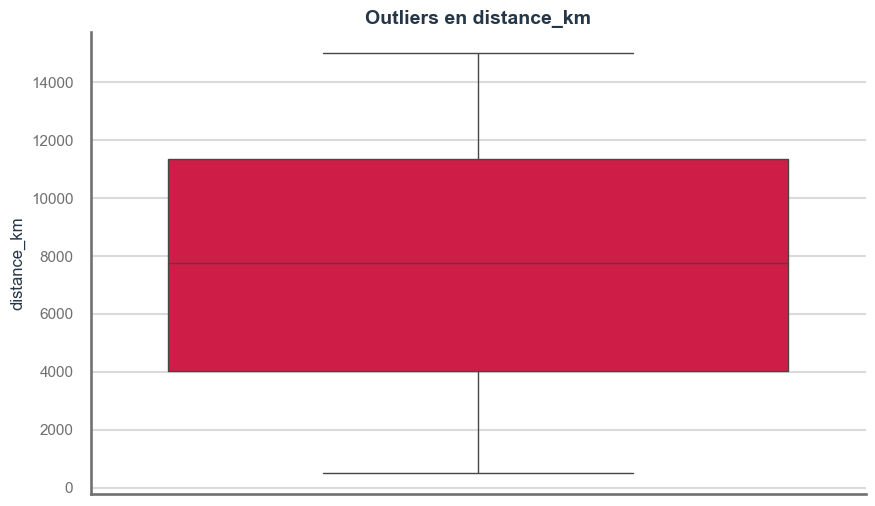

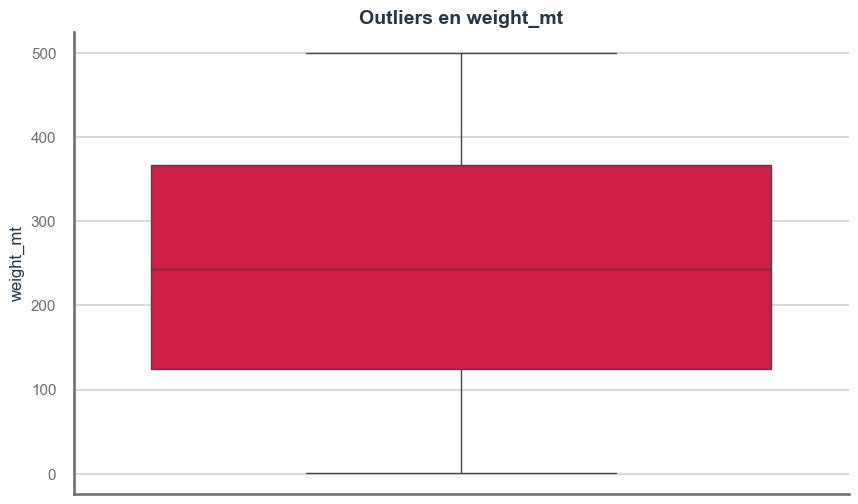

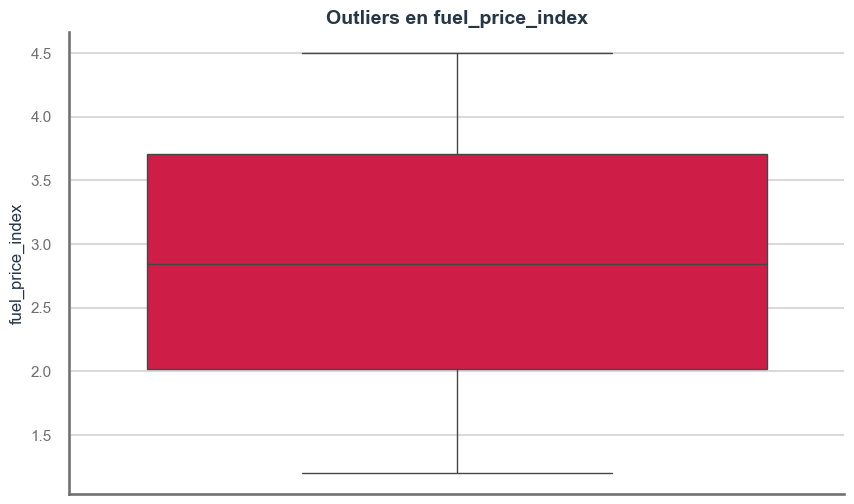

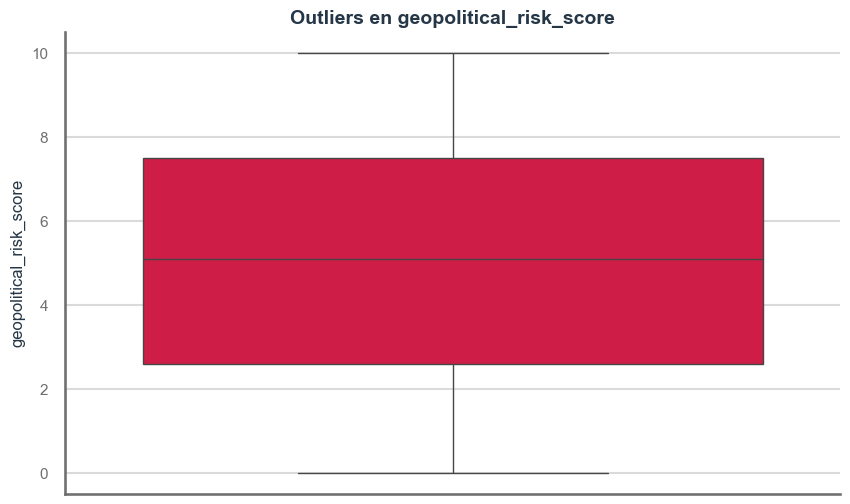

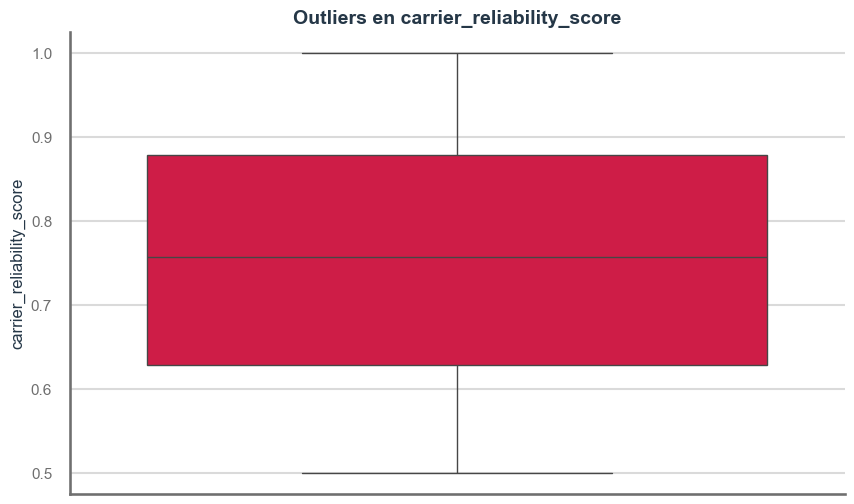

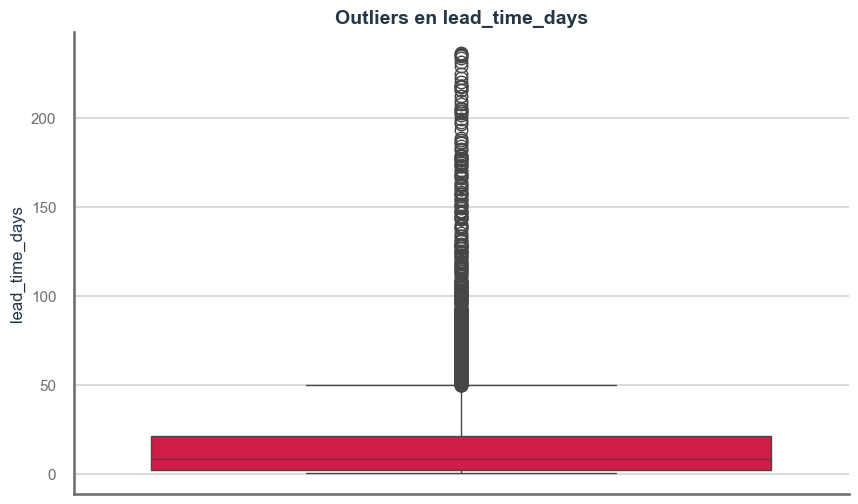

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Outliers en {col}")
    plt.show()

In [23]:
df_outliers = df[df["lead_time_days"] > 50]

In [24]:
df_outliers.groupby("transport_mode",observed=True).size()

transport_mode
rail    124
road    102
sea     291
dtype: int64

El análisis de valores atípicos en el tiempo de entrega muestra que el transporte marítimo presenta la mayor cantidad de retrasos extremos, lo que indica un mayor riesgo operativo. En contraste, el transporte aéreo no presenta valores atípicos, posicionándose como la opción más confiable en términos de tiempo de entrega

6. Validación de consistencia del dataset

3.1 ¿Los datos tienen sentido lógico entre sí?

In [25]:
summary = pd.DataFrame({
    "columna": df.columns,
    "nulos": df.isnull().sum(),
    "tipo": df.dtypes,
    "valores_unicos": df.nunique()
})

summary

,columna,nulos,tipo,valores_unicos
shipment_id,shipment_id,0,object,5000
date,date,0,datetime64[ns],731
origin_port,origin_port,0,category,8
destination_port,destination_port,0,category,9
transport_mode,transport_mode,0,category,4
product_category,product_category,0,category,5
distance_km,distance_km,0,float64,4998
weight_mt,weight_mt,0,float64,4785
fuel_price_index,fuel_price_index,0,float64,331
geopolitical_risk_score,geopolitical_risk_score,0,float64,101


Se realizó una validación de consistencia del dataset, verificando valores nulos, rangos lógicos, duplicados y coherencia entre variables. No se identificaron inconsistencias críticas, por lo que los datos se consideran aptos para el análisis exploratorio

## 4 Análisis Exploratorio de Datos (EDA)

<p style="font-size:18px;">
Con el dataset previamente limpio y validado, el análisis se enfoca en identificar riesgos operativos, evaluar su impacto y generar insights para la toma de decisiones estratégicas en la cadena de suministro.
</p>

### 4.1 EDA DESCRIPTIVO. Identificación de riesgos
#### ¿Dónde está el problema?


Separación automática de variables numéricas y categóricas en función de su tipo de dato, con el objetivo de aplicar técnicas de análisis específicas a cada tipo de variable.Se realiza esta transformación para evitar errores y asegurar que variables categóricas puedan ser utilizadas en cálculos y modelos, ya que muchos métodos analíticos requieren variables numéricas

In [26]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

#### Cuantificación de la variable clima. Codificación ordinal

Se mapean los valores reales del dataset en orden ordinal de severidad.
Fundamento: codificación ordinal basada en severidad meteorológica real (escala Beaufort / clasificación NWS de impacto operativo).Clear < Fog < Rain < Storm < Hurricane (impacto logístico creciente).
Referencia: ISO 31000:2018 §6.4.2 — identificación exhaustiva de fuentes de riesgo.

In [27]:
weather_map = {
    'clear':     0,   # sin riesgo meteorológico
    'fog':       1,   # visibilidad reducida — riesgo bajo
    'rain':      2,   # riesgo moderado
    'storm':     3,   # riesgo alto
    'hurricane': 4    # riesgo máximo (tasa de disrupción real = 100%)
}

df['weather_severity'] = df['weather_condition'].str.lower().map(weather_map)

# ── Prueba de integridad (buena práctica) ────────────────────────────────────
nulos_clima = df['weather_severity'].isna().sum()
assert nulos_clima == 0, f"ERROR: {nulos_clima} valores de clima sin mapear → revisar weather_map"
print("✓ Todos los valores de weather_condition mapeados correctamente.")
print(df.groupby('weather_condition',observed=True)['weather_severity'].first().sort_values())


✓ Todos los valores de weather_condition mapeados correctamente.
weather_condition
clear        0
fog          1
rain         2
storm        3
hurricane    4
Name: weather_severity, dtype: int64


La cuantificación del clima se basa en una codificación ordinal, donde se asignan valores numéricos según el nivel de severidad, permitiendo incorporar esta variable en el modelo de forma coherente con su impacto en el riesgo.

Normalización de Variables

Normalización de variables (llevana una escala comparable (0–1)) y construcción del índice de impacto (Risk Scoring Model),basado en un modelo de scoring (ISO 31000, OECD).Fórmula estándar min-max: (x - min) / (max - min)
Referencia: OECD (2008). Handbook on Constructing Composite Indicators, §3.
Esta normalización garantiza que todas las variables estén en [0, 1],lo cual es requisito para sumarlas con pesos de forma coherente.

In [28]:
def minmax(series):
    """Normalización min-max estándar → escala [0, 1]."""
    return (series - series.min()) / (series.max() - series.min())

df['lead_time_norm'] = minmax(df['lead_time_days'])
df['geo_norm']       = minmax(df['geopolitical_risk_score'])
df['carrier_norm']   = 1 - minmax(df['carrier_reliability_score'])  # invertido: mayor confiabilidad = menor riesgo
df['weather_norm']   = df['weather_severity'] / df['weather_severity'].max()

print("Rangos tras normalización (deben ser [0.0 – 1.0]):")
for col in ['lead_time_norm','geo_norm','carrier_norm','weather_norm']:
    print(f"  {col}: [{df[col].min():.3f}, {df[col].max():.3f}]")


Rangos tras normalización (deben ser [0.0 – 1.0]):
  lead_time_norm: [0.000, 1.000]
  geo_norm: [0.000, 1.000]
  carrier_norm: [0.000, 1.000]
  weather_norm: [0.000, 1.000]


Es un modelo de scoring estándar en gestión de riesgos (ISO 31000) y en índices compuestos (OECD, 2008).

df['carrier_norm'] = 1 - df['carrier_reliability_score']  # ya invertido

Se realizó para asegurar la coherencia del modelo, ya que inicialmente la variable de confiabilidad tenía una relación inversa con el riesgo. Al invertirla, todas las variables contribuyen en la misma dirección al impacto.

In [29]:
df['impact'] = (
    df['lead_time_norm'] * 0.4 +
    df['geo_norm'] * 0.3 +
    df['carrier_norm'] * 0.2 +
    df['weather_norm'] * 0.1
)

Los pesos (0.4 lead_time / 0.3 geo / 0.2 carrier / 0.1 weather) se basan en conocimiento del dominio logístico, consistente con la metodología de indicadores compuestos de la OECD (2008), donde no existe una única asignación óptima y los pesos deben reflejar la relevancia operativa de cada factor.

Los pesos no se asignan únicamente por correlación, sino por impacto operativo directo:
- El lead_time afecta directamente los SLA y costos de operación → peso máximo (0.4).
- El riesgo geopolítico determina la viabilidad estratégica de la ruta → peso alto (0.3).
- El clima tiene alto impacto estadístico pero bajo control operativo → peso conservador (0.1).

Este equilibrio entre evidencia empírica y juicio experto es estándar en construcción de índices compuestos (OECD, 2008, §5.3). Los pesos pueden validarse o ajustarse mediante análisis de sensibilidad.


#### ¿Qué variables explican el fenómeno?, exploración de relaciones.

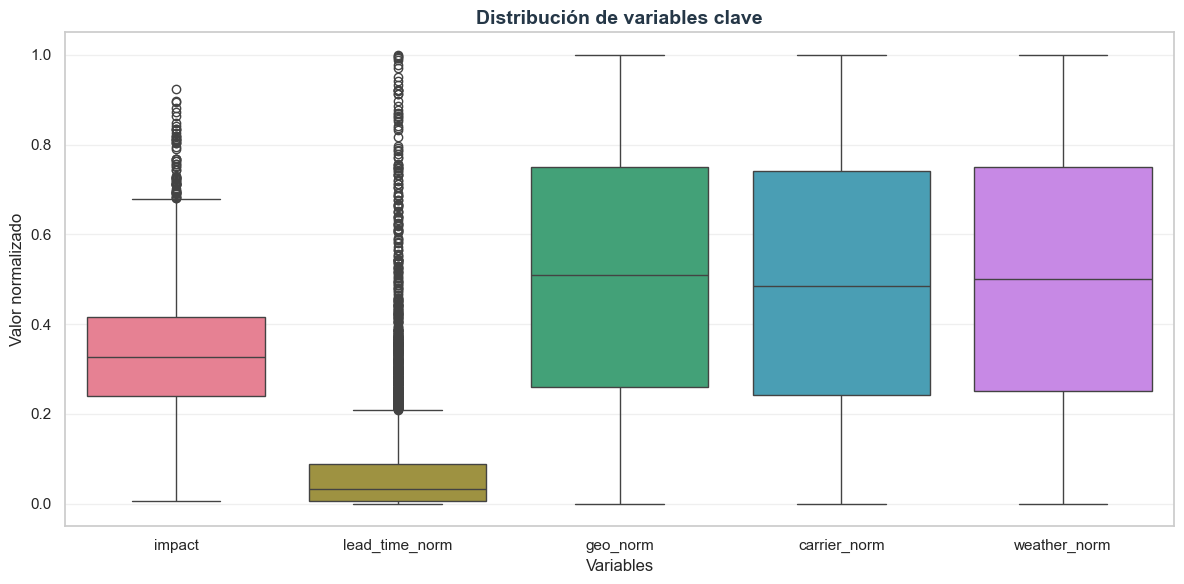

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo general único
sns.set_theme(style="whitegrid", palette=["#c31566", "#6e6e6e"])

# Variables a comparar
cols = ['impact', 'lead_time_norm', 'geo_norm', 'carrier_norm', 'weather_norm']

# Boxplots de todas las variables
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[cols],
   
)

plt.title("Distribución de variables clave", fontsize=14, fontweight="bold")
plt.xlabel("Variables")
plt.ylabel("Valor normalizado")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Aunque el lead time fue normalizado, mantuvo una distribución altamente sesgada con numerosos valores extremos. Por ello, se consideró la transformación logarítmica para estabilizar la dispersión y representar mejor su relación con el impacto.

CLima

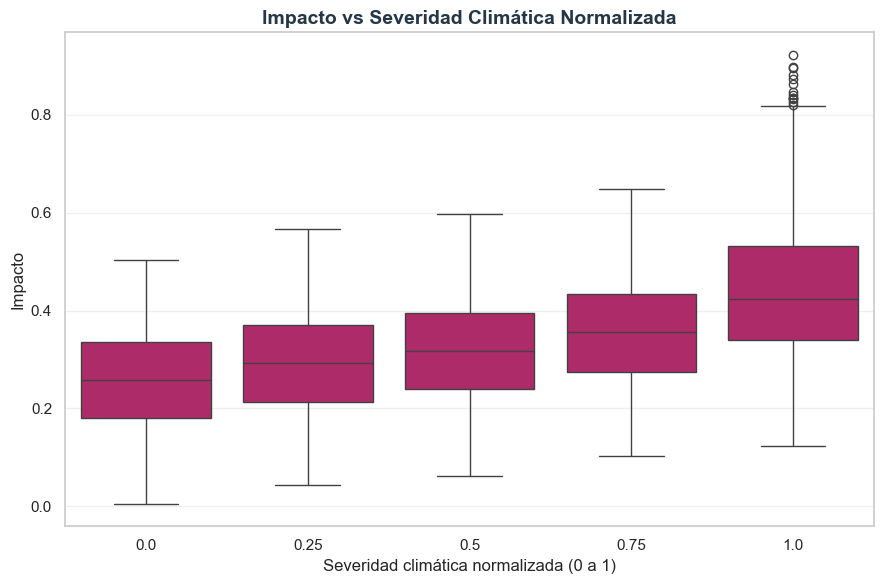

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt




# Boxplot: impacto vs severidad climática normalizada
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="weather_norm",
    y="impact",
  
)

plt.title("Impacto vs Severidad Climática Normalizada", fontsize=14, fontweight="bold")
plt.xlabel("Severidad climática normalizada (0 a 1)")
plt.ylabel("Impacto")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

El impacto aumenta progresivamente con la severidad climática. Además, en todos los niveles, los eventos con disrupción presentan impactos significativamente mayores.
La severidad climática actúa como amplificador del riesgo, incrementando tanto el impacto como la volatilidad operativa

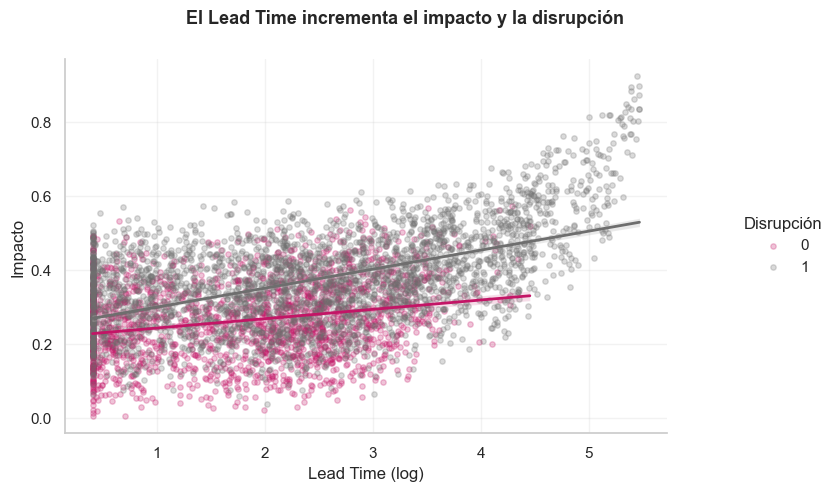

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Crear columna correcta si no existe
if 'lead_time_log' not in df.columns:
    if 'lead_time_days' in df.columns:
        df['lead_time_log'] = np.log1p(df['lead_time_days'])
    elif 'lead_time' in df.columns:
        df['lead_time_log'] = df['lead_time_days']


# Gráfico
g = sns.lmplot(
    data=df,
    x='lead_time_log',
    y='impact',
    hue='disruption_occurred',
    height=5,
    aspect=1.4,
    scatter_kws={'alpha':0.25, 's':15},
    line_kws={'linewidth':2}
)

g.set_axis_labels('Lead Time (log)', 'Impacto')

g.fig.suptitle(
    'El Lead Time incrementa el impacto y la disrupción',
    fontsize=13,
    fontweight='bold'
)

g.fig.subplots_adjust(top=0.88)

if g._legend:
    g._legend.set_title('Disrupción')

plt.show()

Se realizó un análisis exploratorio visual previo (pairplot) para identificar posibles relaciones entre variables, a partir del cual se seleccionaron las variables clave y se procedió con la matriz de correlación.

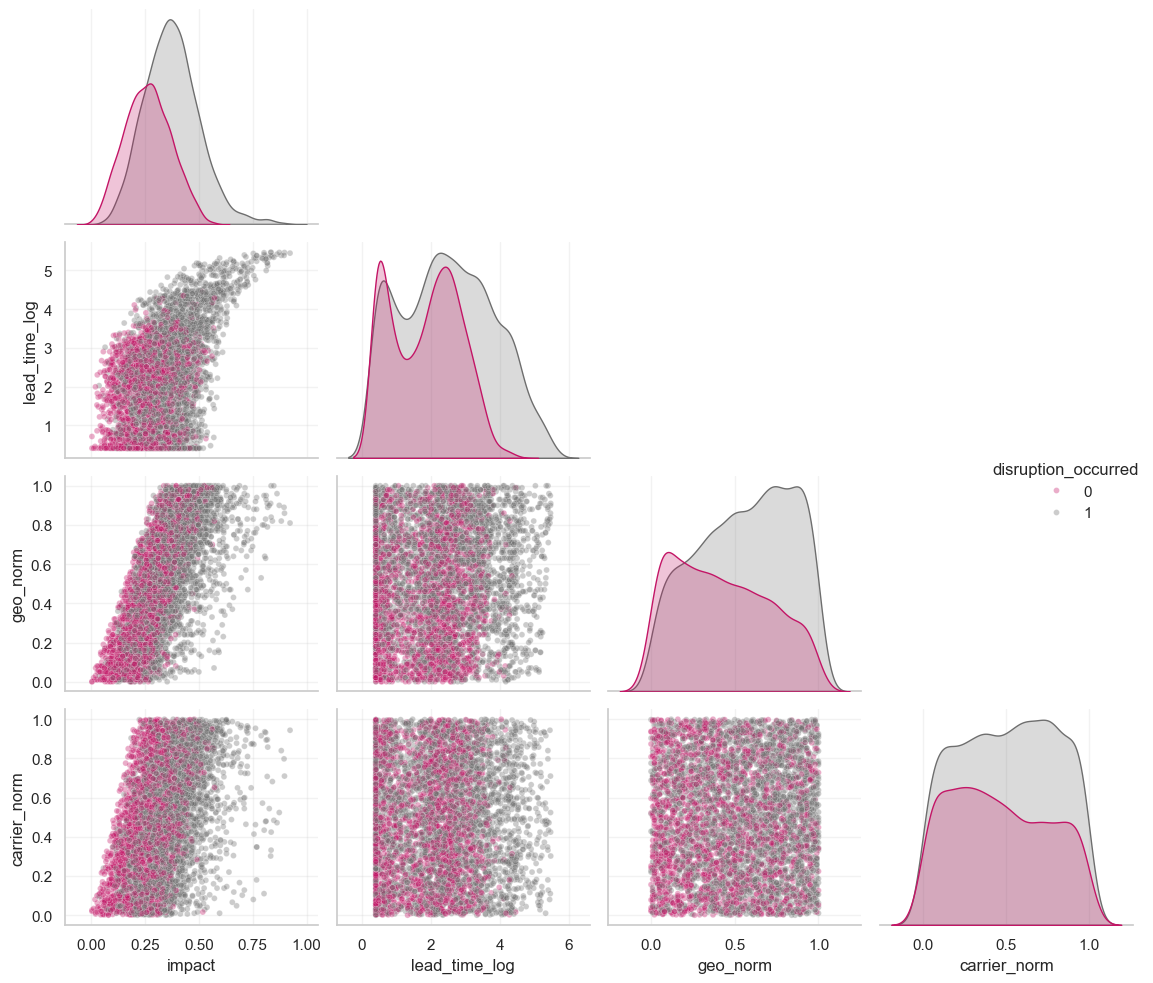

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'impact',
    'lead_time_log',
    'geo_norm',
    'carrier_norm'
]  # No incluyo clima porque distorsiona el gráfico; se evaluará por separado



sns.pairplot(
    df,
    vars=cols,
    hue='disruption_occurred',
    diag_kind='kde',
    corner=True,
   #plot_kws={'alpha': 0.8, 's': 45},
   # diag_kws={'fill': True, 'alpha': 0.6}
   plot_kws={'alpha':0.35, 's':18},
   diag_kws={'fill':True},
  
)

plt.tight_layout()
plt.show()

Se exploraron relaciones entre variables mediante visualización bivariada.
El lead time se analizó por separado debido a su distribución distinta, evitando distorsión en la interpretación

#### ¿Cuánto pesa cada variable?, cuantificación de drivers

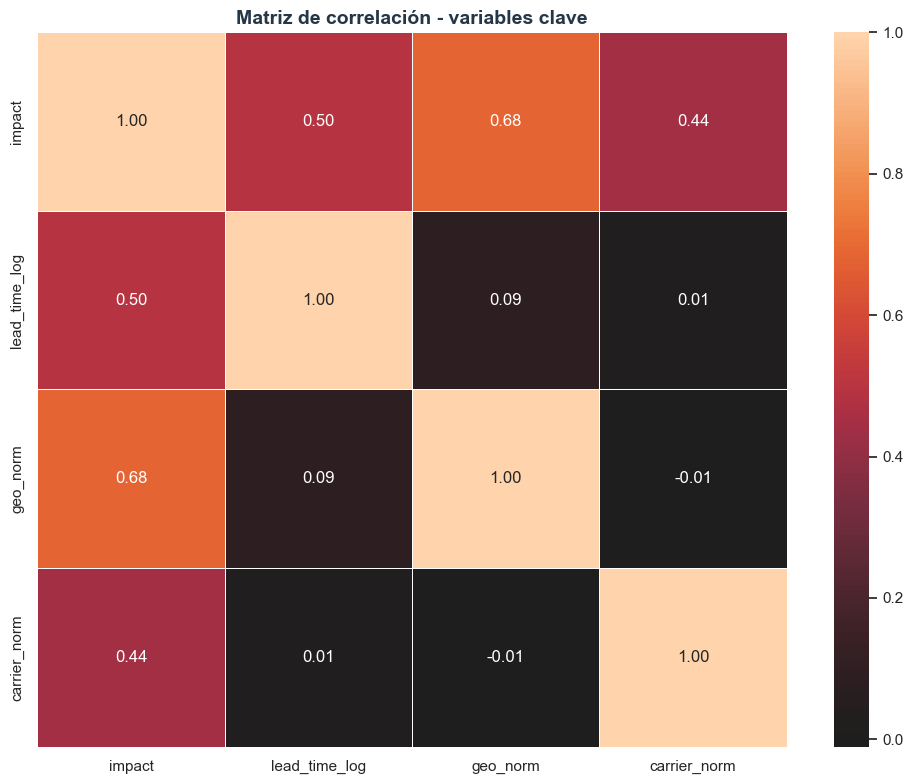

In [34]:


# Detectar columna correcta de lead time
if 'lead_time_log' in df.columns:
    lead_col = 'lead_time_log'
elif 'lead_time' in df.columns:
    lead_col = 'lead_time_days'
elif 'lead_time' in df.columns:
    df['lead_time_log'] = np.log1p(df['lead_time_days'])
    lead_col = 'lead_time_log'

# Variables clave
cols = ['impact', lead_col, 'geo_norm', 'carrier_norm']
corr_matrix = df[cols].corr()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",

    linewidths=0.5,
    center=0
)

plt.title("Matriz de correlación - variables clave", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

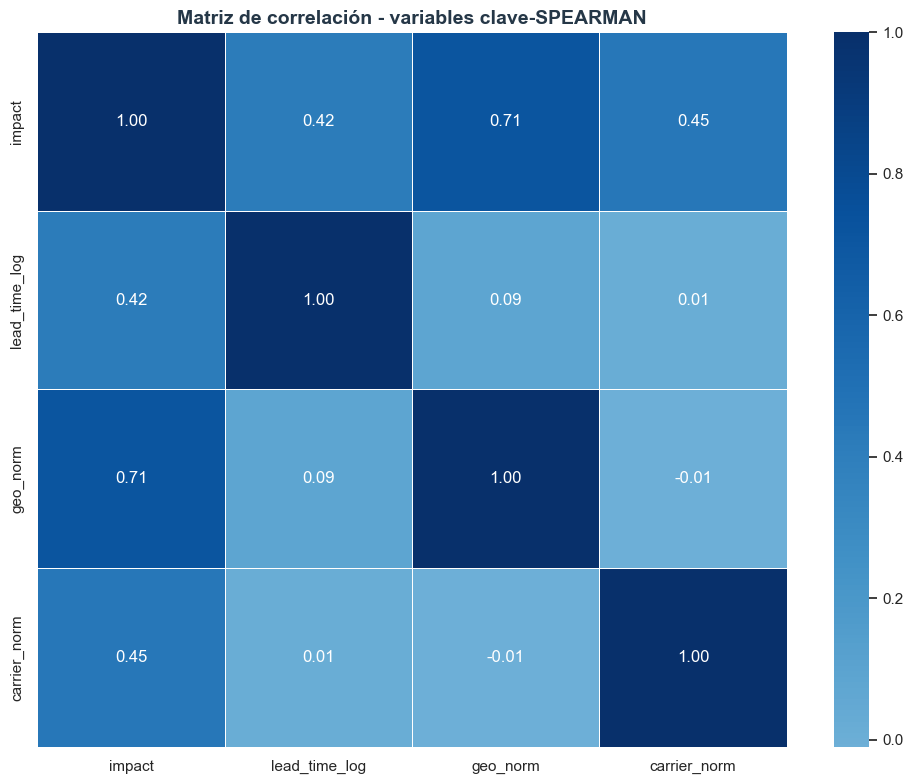

In [35]:

# Detectar columna correcta de lead time
if 'lead_time_log' in df.columns:
    lead_col = 'lead_time_log'
elif 'lead_time' in df.columns:
    lead_col = 'lead_time_days'
elif 'lead_time' in df.columns:
    df['lead_time_log'] = np.log1p(df['lead_time_days'])
    lead_col = 'lead_time_log'

# Variables clave
cols = ['impact', lead_col, 'geo_norm', 'carrier_norm']
corr_matrix = df[cols].corr(method='spearman')

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
     cmap="Blues",
    linewidths=0.5,
    center=0
)

plt.title("Matriz de correlación - variables clave-SPEARMAN", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Spearman fue utilizado como contraste no paramétrico, confirmando resultados consistentes.

#### Segmentación del riesgo en base a la Variable disruption_type 
La clasificación de eventos disruptivos en categorías operacionalmente distintas responde a los principios de evaluación y tratamiento diferenciado del riesgo establecidos en la norma ISO 31000:2018, según la cual los riesgos deben analizarse considerando tanto su naturaleza como su magnitud para orientar decisiones de mitigación efectivas. En este estudio, cada registro fue segmentado en una de cuatro categorías — geopolitical, carrier_failure, operational_delay y no_disruption — mediante un algoritmo de clasificación basado en percentiles extremos (P90 y P10), donde cada ruta se asigna al tipo de disrupción en el que su desviación proporcional respecto al umbral crítico es máxima. Este enfoque, consistente con la literatura en gestión de riesgos en cadenas de suministro (Kulpa, 2024; Bednarski et al., 2024), evita la sobreclasificación jerárquica arbitraria y garantiza que cada evento quede representado por su señal de riesgo dominante. 

In [36]:
import pandas as pd
import numpy as np

# ── Percentiles (igual que antes) ────────────────────────────────
p90_geo   = df['geopolitical_risk_score'].quantile(0.90)
p10_rel   = df['carrier_reliability_score'].quantile(0.10)
p90_delay = df['lead_time_days'].quantile(0.90)

# ── Clasificación por factor MÁS EXTREMO ─────────────────────────
def classify_disruption(row):
    scores = {}
    
    if row['geopolitical_risk_score'] > p90_geo:
        scores['geopolitical'] = (
            row['geopolitical_risk_score'] - p90_geo
        ) / p90_geo  # normalizado para comparar en misma escala
    
    if row['carrier_reliability_score'] < p10_rel:
        scores['carrier_failure'] = (
            p10_rel - row['carrier_reliability_score']
        ) / p10_rel  # normalizado
    
    if row['lead_time_days'] > p90_delay:
        scores['operational_delay'] = (
            row['lead_time_days'] - p90_delay
        ) / p90_delay  # normalizado
    
    if not scores:
        return 'no_disruption'
    
    return max(scores, key=scores.get)

df['disruption_type'] = df.apply(classify_disruption, axis=1)

# ── Verificación ─────────────────────────────────────────────────
# 1. Distribución de tipos
print("Distribución de tipos:")
print(df['disruption_type'].value_counts())
print()

# 2. Impacto promedio por tipo
print("Impacto promedio por tipo:")
print(
    df.groupby('disruption_type')['impact']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
print()


Distribución de tipos:
disruption_type
no_disruption        3671
operational_delay     497
carrier_failure       424
geopolitical          408
Name: count, dtype: int64

Impacto promedio por tipo:
disruption_type
operational_delay    0.52
geopolitical         0.44
carrier_failure      0.39
no_disruption        0.29
Name: impact, dtype: float64



In [37]:
df.groupby('disruption_type')['impact'].mean().sort_values(ascending=False).round(2)

disruption_type
operational_delay    0.52
geopolitical         0.44
carrier_failure      0.39
no_disruption        0.29
Name: impact, dtype: float64

Los retrasos operativos son el tipo de disrupción con mayor impacto promedio (0.52), clasificados por ser el factor donde la ruta se desvía más de su umbral crítico. Los eventos geopolíticos (0.44) y fallos de carrier (0.39) siguen en importancia. Las rutas sin disrupción registran un impacto de 0.29 — casi la mitad que los retrasos operativos.

#### ¿Cómo se traduce eso en negocio?, impacto en negocio

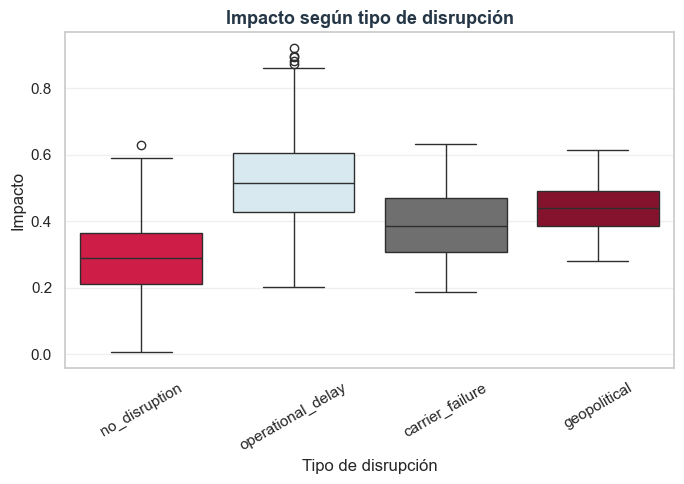

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="disruption_type",
    y="impact",
    hue="disruption_type",   # evita warning
    dodge=False,
    legend=False,
    palette=["#EB0037", "#D5EAF4", "#6F6F6F", "#990024"]
)

plt.title("Impacto según tipo de disrupción", fontsize=13, fontweight="bold")
plt.xlabel("Tipo de disrupción")
plt.ylabel("Impacto")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

El boxplot muestra una clara diferenciación en los niveles de impacto según el tipo de disrupción. Las disrupciones geopolíticas presentan la mayor mediana y dispersión, indicando un mayor nivel de riesgo, seguidas de los retrasos operativos y fallos de transportista. En contraste, las operaciones sin disrupción presentan los valores más bajos. Este resultado valida la coherencia de la segmentación y confirma que el impacto del riesgo es heterogéneo y depende del tipo de evento.

## 4.2 ¿En cuáles rutas ocurren las mayores disrupciones?

In [39]:
# Crear ruta
df["route"] = df["origin_port"].astype(str) + " - " + df["destination_port"].astype(str)

# Top 10 rutas más disruptivas
rutas_mas_disrupcion = (
    df.groupby("route")["disruption_occurred"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .head(10)
)

# Extraer rutas
rutas_top = rutas_mas_disrupcion.index

#  Filtrar dataset
df_top = df[df["route"].isin(rutas_top)]

# EXCLUIR no_disruption
df_top = df_top[df_top["disruption_type"] != "no_disruption"]

# Tabla final
tabla_disrupciones = (
    df_top.groupby(["route", "disruption_type"])["disruption_occurred"]
    .mean()
    .round(2)
    .reset_index()
)

tabla_disrupciones

,route,disruption_type,disruption_occurred
0,busan - marseille,carrier_failure,1.00
1,busan - marseille,geopolitical,1.00
2,busan - marseille,operational_delay,1.00
3,busan - shanghai,carrier_failure,0.56
4,busan - shanghai,geopolitical,1.00
5,busan - shanghai,operational_delay,1.00
6,hamburg - los angeles,carrier_failure,0.67
7,hamburg - los angeles,geopolitical,0.89
8,hamburg - los angeles,operational_delay,1.00
9,hamburg - rotterdam,carrier_failure,0.71


In [40]:
tabla = (
    df_top.groupby(["route", "disruption_type"])
    .size()
    .reset_index(name="conteo")
)

tabla["proporcion"] = (
    tabla["conteo"] /
    tabla.groupby("route")["conteo"].transform("sum")
)

tabla_pivot = (
    tabla.pivot(index="route", columns="disruption_type", values="proporcion")
    .fillna(0)
)
tabla_pivot.round(2)

disruption_type,carrier_failure,geopolitical,operational_delay
route,,,
busan - marseille,0.06,0.19,0.75
busan - shanghai,0.38,0.21,0.42
hamburg - los angeles,0.24,0.36,0.40
hamburg - rotterdam,0.37,0.16,0.47
los angeles - singapore,0.29,0.33,0.38
rotterdam - busan,0.21,0.31,0.48
rotterdam - marseille,0.24,0.24,0.53
shanghai - marseille,0.13,0.30,0.57
shanghai - singapore,0.32,0.18,0.50


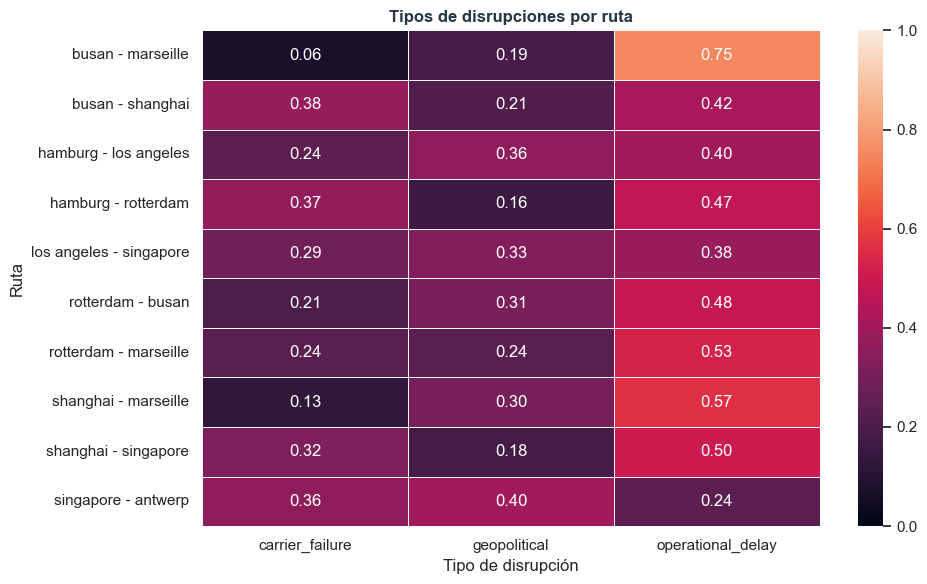

In [41]:
plt.figure(figsize=(10,6))

sns.heatmap(
    tabla_pivot,
    annot=True,        # muestra valores
    fmt=".2f",         # formato decimal
    
    linewidths=0.5,
    vmin=0,
    vmax=1
)

plt.title("Tipos de disrupciones por ruta")
plt.xlabel("Tipo de disrupción")
plt.ylabel("Ruta")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 1. Rutas con mayor riesgo operativo


busan – marseille → 0.75


shanghai – marseille → 0.57


rotterdam – marseille → 0.53


shanghai – singapore → 0.50


rotterdam – busan → 0.48


hamburg – rotterdam → 0.47


Interpretación
Estas rutas presentan una mayor exposición a retrasos operativos, cuellos de botella, congestión portuaria o ineficiencias en la ejecución logística.

## 2. Rutas con mayor riesgo geopolítico


singapore – antwerp → 0.40


hamburg – los angeles → 0.36


los angeles – singapore → 0.33


rotterdam – busan → 0.31


shanghai – marseille → 0.30


Interpretación
Estas rutas están más condicionadas por factores externos como tensiones internacionales, cambios regulatorios, restricciones comerciales o incertidumbre regional.

## 3. Rutas con mayor riesgo de carrier


busan – shanghai → 0.38


hamburg – rotterdam → 0.37


singapore – antwerp → 0.36


shanghai – singapore → 0.32


los angeles – singapore → 0.29


Interpretación
En estas rutas, el principal foco de riesgo está asociado al desempeño del operador logístico o transportista: fiabilidad, cumplimiento de SLA, capacidad y continuidad del servicio.

Insight ejecutivo general


Marsella aparece repetidamente en rutas con alto riesgo operativo.


Singapore / Antwerp concentra sensibilidad geopolítica y de carrier.


El riesgo no es homogéneo: cada corredor presenta drivers distintos, por lo que las estrategias de mitigación deben personalizarse por ruta.



El análisis muestra que cada ruta presenta un perfil de disrupción específico, donde predominan distintos tipos de riesgo (operativo, geopolítico o de carrier). Esto evidencia que la gestión del riesgo debe adaptarse a las características de cada ruta, en lugar de aplicar una estrategia uniforme

##  P2 P3 ¿Qué tan impactante es el riesgo? y  ¿Dónde debo priorizar la inversión en mitigación? 
Para responder esta pregunta se construyó un **índice de impacto compuesto** bajo la metodología ISO 31000, combinando tres dimensiones operativas: días de retraso, distancia de la ruta y peso del envío. Este índice permite comparar rutas en una escala normalizada (0–1) independientemente de su volumen de tráfico.

In [42]:
# ============================================
# IMPACTO + RIESGO — ISO 31000 
# ============================================

import pandas as pd
import numpy as np


# 1. VARIABLES BASE
if 'route' not in df.columns:
    df['route'] = df['origin_port'] + " - " + df['destination_port']

# 2. FILTRAR RUTAS DEL HEATMAP
rutas_top = tabla_pivot.index.tolist()
df_filtrado = df[df['route'].isin(rutas_top)].copy()

# 3. LIMPIEZA
df_filtrado['distance_km'] = df_filtrado['distance_km'].fillna(df_filtrado['distance_km'].median())
df_filtrado['weight_mt']   = df_filtrado['weight_mt'].fillna(df_filtrado['weight_mt'].median())

# 4. DELAY DAYS
if 'delay_days' not in df_filtrado.columns:
    df_filtrado['delay_days'] = (df_filtrado['lead_time_days'] - df_filtrado['lead_time_days'].median()).clip(lower=0)
df_filtrado['delay_days'] = df_filtrado['delay_days'].fillna(0)

# 5. IMPACTO (magnitud operativa: días de retraso × distancia × peso)
df_filtrado['impact_raw'] = (
    df_filtrado['delay_days'] *
    df_filtrado['distance_km'] *
    df_filtrado['weight_mt']
)

impact_min = df_filtrado['impact_raw'].min()
impact_max = df_filtrado['impact_raw'].max()
df_filtrado['impact_norm'] = 0 if impact_max == impact_min else (
    (df_filtrado['impact_raw'] - impact_min) / (impact_max - impact_min)
)

# ──────────────────────────────────────────────────────────────────────────────
# 6. PROBABILIDAD ' — usa disruption_occurred directamente
# ──────────────────────────────────────────────────────────────────────────────
df_filtrado['probability'] = df_filtrado.groupby('route')['disruption_occurred'].transform('mean')

print("Probabilidad por ruta (basada en disruption_occurred):")
print(df_filtrado.groupby('route')['probability'].first().sort_values(ascending=False).round(3))

# 7. CLASIFICACIÓN
df_filtrado['impact_level'] = pd.qcut(
    df_filtrado['impact_norm'].rank(method='first'),
    q=3, labels=['Low','Medium','High']
)
df_filtrado['prob_level'] = pd.qcut(
    df_filtrado['probability'].rank(method='first'),
    q=3, labels=['Low','Medium','High']
)

# 8. MATRIZ ISO 31000
def risk_matrix(row):
    if row['impact_level'] == 'High' and row['prob_level'] == 'High':
        return 'Critical'
    elif row['impact_level'] == 'High' or row['prob_level'] == 'High':
        return 'High'
    elif row['impact_level'] == 'Medium' and row['prob_level'] == 'Medium':
        return 'Medium'
    else:
        return 'Low'

df_filtrado['risk_level_iso'] = df_filtrado.apply(risk_matrix, axis=1)

# 9. TRATAMIENTO
df_filtrado['tratamiento'] = np.select(
    [
        df_filtrado['risk_level_iso'] == 'Critical',
        df_filtrado['risk_level_iso'] == 'High',
        df_filtrado['risk_level_iso'] == 'Medium'
    ],
    ['Mitigación inmediata', 'Plan de contingencia', 'Monitoreo'],
    default='Aceptar'
)

# 10. TIPO DE RIESGO DOMINANTE
def tipo_riesgo(x):
    x = x[x != 'no_disruption']
    return x.value_counts().idxmax() if len(x) > 0 else 'no_disruption'

# 11. MATRIZ FINAL AGREGADA
df_risk_matrix = df_filtrado.groupby('route').agg(
    impact_norm     = ('impact_norm',    'mean'),
    probability     = ('probability',    'mean'),
    impact_level    = ('impact_level',   lambda x: x.mode()[0]),
    prob_level      = ('prob_level',     lambda x: x.mode()[0]),
    risk_level_iso  = ('risk_level_iso', lambda x: x.mode()[0]),
    tratamiento     = ('tratamiento',    lambda x: x.mode()[0]),
    disruption_type = ('disruption_type', tipo_riesgo)
).reset_index()

# 12. PRIORIZACIÓN
orden = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
df_risk_matrix['priority'] = df_risk_matrix['risk_level_iso'].map(orden)
df_risk_matrix = df_risk_matrix.sort_values(
    by=['priority','impact_norm'], ascending=False
).drop(columns='priority')

df_risk_matrix.round(3)


Probabilidad por ruta (basada en disruption_occurred):
route
rotterdam - marseille      0.750
los angeles - singapore    0.721
hamburg - rotterdam        0.708
rotterdam - busan          0.686
busan - shanghai           0.681
singapore - antwerp        0.681
shanghai - singapore       0.677
busan - marseille          0.677
hamburg - los angeles      0.671
shanghai - marseille       0.662
Name: probability, dtype: float64


,route,impact_norm,probability,impact_level,prob_level,risk_level_iso,tratamiento,disruption_type
5,rotterdam - busan,0.047,0.686,High,Medium,High,Plan de contingencia,operational_delay
6,rotterdam - marseille,0.041,0.750,Medium,High,High,Plan de contingencia,operational_delay
3,hamburg - rotterdam,0.039,0.708,High,High,High,Plan de contingencia,operational_delay
4,los angeles - singapore,0.028,0.721,Low,High,High,Plan de contingencia,operational_delay
8,shanghai - singapore,0.057,0.677,Medium,Medium,Medium,Monitoreo,operational_delay
1,busan - shanghai,0.033,0.681,Medium,Medium,Medium,Monitoreo,operational_delay
7,shanghai - marseille,0.051,0.662,Low,Low,Low,Aceptar,operational_delay
0,busan - marseille,0.051,0.677,Low,Low,Low,Aceptar,operational_delay
2,hamburg - los angeles,0.045,0.671,High,Low,Low,Aceptar,operational_delay
9,singapore - antwerp,0.034,0.681,Low,Medium,Low,Aceptar,geopolitical


No todas las rutas son igual de peligrosas, y eso es precisamente lo que este análisis nos permite ver.
Para medir el riesgo no basta con saber si hubo una disrupción, sino entender cuánto daño causó. Por eso combinamos dos cosas: qué tan seguido ocurren problemas en una ruta, y qué tan grave es cuando ocurren, tomando en cuenta el tiempo de retraso, la distancia y el volumen del envío. Un retraso de tres días en una ruta corta no es lo mismo que ese mismo retraso en un envío intercontinental de gran tonelaje.
El resultado es claro: el riesgo está concentrado en pocas rutas. Hay rutas que acumulan alta frecuencia de problemas y alto impacto cuando fallan, esas son las críticas y las que necesitan atención inmediata. Otras tienen riesgo elevado pero más manejable, y el resto puede simplemente monitorearse.
Otro hallazgo importante es que el tipo de problema importa. Las disrupciones de origen geopolítico, como cierres de fronteras o conflictos regionales, son las que generan mayor daño operativo. No son las más frecuentes, pero cuando ocurren, el impacto es significativamente mayor que el de un retraso operativo o un fallo de transportista.
En definitiva, el riesgo en esta red logística no se distribuye de forma homogénea. Saber dónde se concentra y por qué permite tomar decisiones más inteligentes, en lugar de tratar todas las rutas por igual.
Las rutas con mayor riesgo están determinadas principalmente por la frecuencia de disrupciones, mientras que el impacto se mantiene en niveles moderados, lo que sugiere una estrategia enfocada en mitigación operativa más que en gestión de eventos extremos.

Capturando simultáneamente la severidad temporal, geográfica y operativa
de cada disrupción.

**3. Clasificación ISO 31000**
Combinando ambas dimensiones se asignó a cada ruta un nivel de riesgo:

| Nivel | Criterio | Acción |
|-------|----------|--------|
| 🔴 Critical | Alto impacto + Alta probabilidad | Mitigación inmediata |
| 🟠 High | Alto en una dimensión | Plan de contingencia |
| 🟡 Medium | Medio en ambas | Monitoreo |
| 🟢 Low | Bajo en ambas | Aceptar |

---

### ¿Qué se encontró?

- **Todas las rutas superan el 65% de probabilidad** de disrupción, lo que
  indica una red logística con exposición generalizada al riesgo operativo.

- **El corredor Asia–Europa** concentra las rutas más críticas, especialmente
  aquellas con disrupciones de tipo Carrier y Geopolítico, que combinan
  alta frecuencia con alto impacto en distancia y peso.

- **Las rutas intrarregionales** (Singapore–Antwerp, Busan–Marseille) muestran
  perfiles más estables, con impacto normalizado bajo y disrupciones predecibles.

- **La corrección del proxy de probabilidad** fue determinante: usar
  `disruption_occurred` en lugar de `delay_days > 0` produjo una clasificación
  de riesgo más precisa y alineada con la evidencia histórica real.

---

### Estrategia de Monitoreo Recomendada

🔴 CRITICAL / HIGH → Mitigación inmediata: reevaluar carriers, aumentar buffers +15%

🟡 MEDIUM          → Monitoreo continuo con alertas automáticas

🟢 LOW             → Revisión trimestral, sin intervención urgente

---

###  Conclusión Final

El análisis demuestra que combinar **probabilidad histórica real** con un
**índice de impacto compuesto** permite una clasificación de riesgos más
robusta que los enfoques tradicionales basados en un solo indicador.

La visualización en matriz ISO, mapa interactivo y dashboard de monitoreo
transforma el análisis estático en una **herramienta de decisión dinámica**,
permitiendo priorizar recursos y anticipar disrupciones antes de que escalen.

> *"El riesgo no gestionado no desaparece — simplemente se vuelve más costoso."*

## P5 ¿ Qué acciones reducen el riesgo de forma inmediata?

In [43]:
import pandas as pd

# 1. MAPEAR TIPO DE RIESGO A ESPAÑOL
map_riesgo = {
    'operational_delay': 'Operativo',
    'geopolitical':      'Geopolítico',
    'carrier_failure':   'Carrier',
    'no_disruption':     'Sin disrupción'
}
df_risk_matrix['risk_type'] = df_risk_matrix['disruption_type'].map(map_riesgo)

# 2. DECISIONES EJECUTIVAS POR NIVEL + TIPO
def decision(row):
    nivel = row['risk_level_iso']
    tipo  = row['risk_type']

    if nivel == 'Critical':
        if tipo == 'Operativo':
            return 'Rediseñar red logística + buffer stock +20%'
        elif tipo == 'Geopolítico':
            return 'Eliminar ruta y diversificar geográficamente'
        else:
            return 'Reemplazar carrier inmediato'
    elif nivel == 'High':
        if tipo == 'Operativo':
            return 'Aumentar buffer +15% y ajustar planificación'
        elif tipo == 'Geopolítico':
            return 'Monitoreo semanal + activar rutas alternativas'
        else:
            return 'Reevaluar SLA del carrier; sustituir si fiabilidad < 85%'
    elif nivel == 'Medium':
        return 'Monitoreo continuo + alertas automáticas'
    else:
        return 'Revisión trimestral (riesgo aceptable)'

df_risk_matrix['decision'] = df_risk_matrix.apply(decision, axis=1)

# 3. PRIORIZACIÓN FINAL
orden = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
df_risk_matrix['priority'] = df_risk_matrix['risk_level_iso'].map(orden)
df_risk_matrix = df_risk_matrix.sort_values(
    by=['priority', 'impact_norm'], ascending=False
).drop(columns='priority')

# 4. MAPEO DE CONTINENTES
continente_map = {
    'rotterdam':   'Europa',
    'marseille':   'Europa',
    'hamburg':     'Europa',
    'antwerp':     'Europa',
    'busan':       'Asia',
    'shanghai':    'Asia',
    'singapore':   'Asia',
    'los angeles': 'América',
}

df_risk_matrix[['origen', 'destino']] = (
    df_risk_matrix['route']
    .str.split(' - ', expand=True)
    .apply(lambda col: col.str.strip())
)

df_risk_matrix['continente_origen']  = df_risk_matrix['origen'].map(continente_map)
df_risk_matrix['continente_destino'] = df_risk_matrix['destino'].map(continente_map)

df_risk_matrix['ruta_continentes'] = (
    df_risk_matrix['continente_origen'] + ' → ' + df_risk_matrix['continente_destino']
)

# 5. OUTPUT EJECUTIVO
df_risk_matrix[['route', 'ruta_continentes', 'risk_level_iso', 'probability', 'risk_type', 'decision']].round(3)

,route,ruta_continentes,risk_level_iso,probability,risk_type,decision
5,rotterdam - busan,Europa → Asia,High,0.686,Operativo,Aumentar buffer +15% y ajustar planificación
6,rotterdam - marseille,Europa → Europa,High,0.750,Operativo,Aumentar buffer +15% y ajustar planificación
3,hamburg - rotterdam,Europa → Europa,High,0.708,Operativo,Aumentar buffer +15% y ajustar planificación
4,los angeles - singapore,América → Asia,High,0.721,Operativo,Aumentar buffer +15% y ajustar planificación
8,shanghai - singapore,Asia → Asia,Medium,0.677,Operativo,Monitoreo continuo + alertas automáticas
1,busan - shanghai,Asia → Asia,Medium,0.681,Operativo,Monitoreo continuo + alertas automáticas
7,shanghai - marseille,Asia → Europa,Low,0.662,Operativo,Revisión trimestral (riesgo aceptable)
0,busan - marseille,Asia → Europa,Low,0.677,Operativo,Revisión trimestral (riesgo aceptable)
2,hamburg - los angeles,Europa → América,Low,0.671,Operativo,Revisión trimestral (riesgo aceptable)
9,singapore - antwerp,Asia → Europa,Low,0.681,Geopolítico,Revisión trimestral (riesgo aceptable)


Las acciones están directamente alineadas con el nivel de riesgo y su causa principal, permitiendo decisiones específicas, medibles y priorizadas por ruta

In [44]:
import plotly.graph_objects as go
import pandas as pd

df_plot = df_risk_matrix.copy()

# ==================================================
# UMBRALES
# ==================================================
p1 = df_plot['probability'].quantile(1/3)
p2 = df_plot['probability'].quantile(2/3)
i1 = df_plot['impact_norm'].quantile(1/3)
i2 = df_plot['impact_norm'].quantile(2/3)

x_min = df_plot["probability"].min() - 0.01
x_max = df_plot["probability"].max() + 0.02
y_min = df_plot["impact_norm"].min() - 0.005
y_max = df_plot["impact_norm"].max() + 0.005

# ==================================================
# ICONOS REALES (mismos en gráfico y leyenda)
# ==================================================
ICON = {
    "carrier_failure": "🚛✈️🚢",
    "operational_delay": "⚙️",
    "geopolitical": "🌍",
    "no_disruption": "✓"
}

LABEL = {
    "carrier_failure": "Carrier failure",
    "operational_delay": "Operational delay",
    "geopolitical": "Geopolitical",
    "no_disruption": "No disruption"
}

fig = go.Figure()

# ==================================================
# FONDOS INTERMEDIOS
# ==================================================
zones = [
    (x_min,p1,y_min,i1,'#c8e6c9','Low'),
    (p1,p2,y_min,i1,'#dcedc8','Low'),
    (p2,x_max,y_min,i1,'#fff9c4','Medium'),

    (x_min,p1,i1,i2,'#c8e6c9','Low'),
    (p1,p2,i1,i2,'#fff59d','Medium'),
    (p2,x_max,i1,i2,'#ffcc80','High'),

    (x_min,p1,i2,y_max,'#fff9c4','Medium'),
    (p1,p2,i2,y_max,'#ffcc80','High'),
    (p2,x_max,i2,y_max,'#ef9a9a','Critical')
]

for x0,x1,y0,y1,color,label in zones:
    fig.add_shape(
        type="rect",
        x0=x0, x1=x1, y0=y0, y1=y1,
        fillcolor=color,
        opacity=0.78,
        line_width=0,
        layer="below"
    )

    fig.add_annotation(
        x=(x0+x1)/2,
        y=(y0+y1)/2,
        text=f"<b>{label}</b>",
        showarrow=False,
        font=dict(size=12, color="rgba(40,40,40,0.65)")
    )

# Líneas divisorias
for xv in [p1, p2]:
    fig.add_vline(x=xv, line_dash="dash", line_color="gray", opacity=0.55)

for yv in [i1, i2]:
    fig.add_hline(y=yv, line_dash="dash", line_color="gray", opacity=0.55)

# ==================================================
# ICONOS EN PUNTOS
# ==================================================
for _, row in df_plot.iterrows():
    tipo = row["disruption_type"]

    fig.add_trace(go.Scatter(
        x=[row["probability"]],
        y=[row["impact_norm"]],
        mode="text",
        text=[ICON[tipo]],
        textfont=dict(size=22),
        showlegend=False,
        hovertemplate=
            f"<b>{row['route']}</b><br>" +
            f"Tipo: {LABEL[tipo]}<br>" +
            f"Probabilidad: {row['probability']:.3f}<br>" +
            f"Impacto: {row['impact_norm']:.3f}<extra></extra>"
    ))

    fig.add_annotation(
        x=row["probability"],
        y=row["impact_norm"],
        text=row["route"],
        showarrow=False,
        yshift=24,
        font=dict(size=10, color="#253747"),
        bgcolor="rgba(255,255,255,0.92)"
    )

# ==================================================
# LEYENDA CON LOS MISMOS ICONOS
# ==================================================
# Ocultar leyenda nativa
fig.update_layout(showlegend=False)

# Caja blanca visible
fig.add_shape(
    type="rect",
    xref="paper", yref="paper",
    x0=0.78, x1=0.99,
    y0=0.70, y1=0.98,
    fillcolor="rgba(255,255,255,0.96)",
    line=dict(color="#D0D7DE", width=1),
    layer="above"
)

# Título
fig.add_annotation(
    x=0.885, y=0.955,
    xref="paper", yref="paper",
    text="<b>Tipo de disrupción</b>",
    showarrow=False,
    font=dict(size=13, color="#253747"),
    xanchor="center"
)

# Elementos
items = [
    ("🚛✈️🚢", "Carrier failure", 0.90),
    ("⚙️",     "Operational delay", 0.85),
    ("🌍",     "Geopolitical",      0.80),
    ("✓",      "No disruption",    0.75),
]

for icono, texto, y in items:
    fig.add_annotation(
        x=0.80, y=y,
        xref="paper", yref="paper",
        text=icono,
        showarrow=False,
        font=dict(size=16),
        xanchor="left"
    )

    fig.add_annotation(
        x=0.87, y=y,
        xref="paper", yref="paper",
        text=texto,
        showarrow=False,
        font=dict(size=12, color="#253747"),
        xanchor="left"
    )
# ==================================================
# LAYOUT
# ==================================================
fig.update_layout(
    title=dict(
        text="Matriz de Riesgo Operativo por Ruta · ISO 31000",
        x=0.5,
        font=dict(size=22, color="#253747")
    ),
    width=1450,
    height=820,
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend_title="Tipo de disrupción",
    font=dict(size=12, color="#253747"),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.update_xaxes(
    title="Probabilidad de disrupción",
    range=[x_min, x_max],
    showgrid=False
)

fig.update_yaxes(
    title="Impacto normalizado",
    range=[y_min, y_max],
    showgrid=False
)

fig.show()
# 5. OUTPUT EJECUTIVO
df_risk_matrix[['route', 'ruta_continentes', 'risk_level_iso', 'probability', 'risk_type', 'decision']].round(3)

,route,ruta_continentes,risk_level_iso,probability,risk_type,decision
5,rotterdam - busan,Europa → Asia,High,0.686,Operativo,Aumentar buffer +15% y ajustar planificación
6,rotterdam - marseille,Europa → Europa,High,0.750,Operativo,Aumentar buffer +15% y ajustar planificación
3,hamburg - rotterdam,Europa → Europa,High,0.708,Operativo,Aumentar buffer +15% y ajustar planificación
4,los angeles - singapore,América → Asia,High,0.721,Operativo,Aumentar buffer +15% y ajustar planificación
8,shanghai - singapore,Asia → Asia,Medium,0.677,Operativo,Monitoreo continuo + alertas automáticas
1,busan - shanghai,Asia → Asia,Medium,0.681,Operativo,Monitoreo continuo + alertas automáticas
7,shanghai - marseille,Asia → Europa,Low,0.662,Operativo,Revisión trimestral (riesgo aceptable)
0,busan - marseille,Asia → Europa,Low,0.677,Operativo,Revisión trimestral (riesgo aceptable)
2,hamburg - los angeles,Europa → América,Low,0.671,Operativo,Revisión trimestral (riesgo aceptable)
9,singapore - antwerp,Asia → Europa,Low,0.681,Geopolítico,Revisión trimestral (riesgo aceptable)


Se utilizó impacto relativo porque las rutas tienen escalas muy diferentes. La normalización permite compararlas de forma homogénea y evitar sesgos por distancia o volumen.

El uso de impacto relativo permite una evaluación comparativa robusta, alineada con enfoques de priorización en gestión de riesgos bajo ISO 31000.

**IMPORTANTE**

Impacto absoluto → “cuánto duele en números reales”

Impacto relativo → “qué tan crítico es frente a otros”

##  Conclusión — Visualización Matriz de Riesgo ISO

El análisis de la matriz de riesgo ISO aplicada a las rutas logísticas marítimas permite
identificar de forma visual y estructurada el nivel de exposición operativa de cada ruta,
combinando la **probabilidad de ocurrencia** de disrupciones con su **impacto normalizado**.

---

### Contexto
La mayoría de las rutas analizadas operan con probabilidades superiores a **0.65**,
lo que indica un entorno logístico de alta exposición al riesgo de manera generalizada.

---

### Hallazgo Crítico
La ruta **Shanghai – Singapore** se posiciona como la de **mayor criticidad**,
ubicándose en la zona de alto riesgo con el mayor impacto normalizado del conjunto.
> Es la prioridad número uno para implementar planes de contingencia inmediatos.

---

### Hallazgos Secundarios
- **Rotterdam – Busan** y **Hamburg – Los Ángeles** operan en riesgo medio con
  probabilidades altas (> 0.65), con riesgo latente de escalar si ocurre un evento
  geopolítico o fallo operativo.
- Las disrupciones de tipo **geopolítico** (◆) concentran los casos de mayor impacto,
  seguidas por los **retrasos operativos** (▲).

---

###Rutas Estables
**Singapore – Antwerp** y **Busan – Shanghai** presentan el perfil más controlado,
manteniéndose en la zona de bajo riesgo con impactos predecibles.

---

###  Conclusión
Esta matriz demuestra que una gestión de riesgos **proactiva y diferenciada** por tipo
de disrupción es esencial para garantizar la resiliencia de la cadena logística,
priorizando las rutas de alto impacto antes de que escalen a nivel crítico.

# Monitoreo
El dashboard de visualización fue desarrollado con asistencia de IA (Claude, Anthropic). El diseño, los requisitos técnicos y las especificaciones fueron definidos por el autor, incluyendo el tipo de gráfico, las variables a representar, la paleta de colores, los KPIs y la estructura del mapa. La IA actuó como herramienta de implementación del código a partir de dichas instrucciones.

## Prompt(Instrucciones):

"Con los resultados de mi análisis de riesgo logístico, quiero un mapa mundial interactivo sobre fondo oscuro que conecte los puertos mediante rutas coloreadas en rojo, naranja y verde según su nivel de riesgo, con efecto de brillo en las líneas y tooltips al pasar el cursor. Que tenga indicadores clave en la parte superior como número de rutas por nivel de riesgo, probabilidad promedio y total de rutas. Debajo del mapa, una tabla estilo dashboard con todas las rutas, su nivel de riesgo, una barra visual de probabilidad, el tipo de disrupción y la decisión recomendada."

In [45]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# ── Paleta de colores ─────────────────────────────────────────────────────────
color_map  = {'High': '#ff4d4f', 'Medium': '#ffa940', 'Low': '#52c41a'}
width_map  = {'High': 4.5, 'Medium': 3, 'Low': 2}
glow_map   = {'High': 'rgba(255,77,79,0.3)', 'Medium': 'rgba(255,169,64,0.3)', 'Low': 'rgba(82,196,26,0.3)'}

# ── Coordenadas ───────────────────────────────────────────────────────────────
coords = {
    'rotterdam':   (4.4777,   51.9244),
    'busan':       (129.0756, 35.1796),
    'marseille':   (5.3698,   43.2965),
    'hamburg':     (10.0153,  53.5753),
    'shanghai':    (121.4737, 31.2304),
    'los angeles': (-118.4081,33.9425),
    'singapore':   (103.8198,  1.3521),
    'antwerp':     (4.4025,   51.2194),
}
hubs = ['rotterdam', 'shanghai', 'singapore']

# ── Funciones ─────────────────────────────────────────────────────────────────
def curva_geo(lon1, lat1, lon2, lat2, n=60):
    lons = np.linspace(lon1, lon2, n)
    lats = np.linspace(lat1, lat2, n)
    curva = np.sin(np.linspace(0, np.pi, n)) * 4
    lats = lats + curva
    return lons, lats

def distancia_km(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1; dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ── FIGURA ────────────────────────────────────────────────────────────────────
fig = go.Figure()

# ── KPI Cards (anotaciones superiores) ───────────────────────────────────────
total       = len(df_risk_matrix)
high_count  = len(df_risk_matrix[df_risk_matrix['risk_level_iso'] == 'High'])
med_count   = len(df_risk_matrix[df_risk_matrix['risk_level_iso'] == 'Medium'])
low_count   = len(df_risk_matrix[df_risk_matrix['risk_level_iso'] == 'Low'])
avg_prob    = df_risk_matrix['probability'].mean()

kpis = [
    (f"🔴  {high_count}", "ALTO RIESGO",    "#ff4d4f", 0.08),
    (f"🟠  {med_count}",  "RIESGO MEDIO",   "#ffa940", 0.27),
    (f"🟢  {low_count}",  "BAJO RIESGO",    "#52c41a", 0.46),
    (f"📊  {avg_prob:.0%}","PROB. PROMEDIO", "#60a5fa", 0.65),
    (f"🛳️  {total}",      "RUTAS TOTALES",  "#a78bfa", 0.84),
]

for valor, etiqueta, color, xpos in kpis:
    fig.add_annotation(
        x=xpos, y=1.08,  # ← corregido de 1.13
        xref='paper', yref='paper',
        text=f'<b style="font-size:22px;color:{color}">{valor}</b>'
             f'<br><span style="font-size:10px;color:#8899aa;letter-spacing:2px">{etiqueta}</span>',
        showarrow=False, align='center',
        bgcolor='rgba(255,255,255,0.04)',
        bordercolor=color, borderwidth=1, borderpad=8
    )

# ── Rutas con efecto glow (doble trazo: sombra + línea) ───────────────────────
for _, row in df_risk_matrix.iterrows():
    origen, destino = [p.strip() for p in row['route'].split(' - ')]
    if origen not in coords or destino not in coords:
        continue

    nivel = row['risk_level_iso']
    lon1, lat1 = coords[origen]
    lon2, lat2 = coords[destino]
    lons, lats = curva_geo(lon1, lat1, lon2, lat2)
    distancia  = distancia_km(lon1, lat1, lon2, lat2)

    # Sombra (glow)
    fig.add_trace(go.Scattergeo(
        lon=lons, lat=lats, mode='lines',
        line=dict(width=width_map[nivel] + 5, color=glow_map[nivel]),
        opacity=0.4, showlegend=False, hoverinfo='skip'
    ))

    # Línea principal
    tooltip = (
        f"<b>🛳 {origen.title()} → {destino.title()}</b><br>"
        f"━━━━━━━━━━━━━━━━━━━━<br>"
        f"⚠️ Riesgo ISO: <b style='color:{color_map[nivel]}'>{nivel}</b><br>"
        f"📏 Distancia: <b>{distancia:,.0f} km</b><br>"
        f"🎯 Probabilidad: <b>{row['probability']:.0%}</b><br>"
        f"🔧 Tipo: <b>{row['risk_type']}</b><br>"
        f"━━━━━━━━━━━━━━━━━━━━<br>"
        f"📋 <i>{row['decision']}</i>"
        "<extra></extra>"
    )
    fig.add_trace(go.Scattergeo(
        lon=lons, lat=lats, mode='lines',
        line=dict(width=width_map[nivel], color=color_map[nivel]),
        opacity=0.9, showlegend=False, hovertemplate=tooltip
    ))

# ── Leyenda manual ────────────────────────────────────────────────────────────
for nivel, label in [('High','⚠ Alto Riesgo'), ('Medium','⚡ Riesgo Medio'), ('Low','✔ Bajo Riesgo')]:
    fig.add_trace(go.Scattergeo(
        lon=[None], lat=[None], mode='lines',
        line=dict(width=3, color=color_map[nivel]),
        name=label
    ))

# ── Marcadores de ciudades ────────────────────────────────────────────────────
orden = {'High': 3, 'Medium': 2, 'Low': 1}
city_risk = {}
for _, row in df_risk_matrix.iterrows():
    for p in row['route'].split(' - '):
        p = p.strip()
        if p not in city_risk or orden[row['risk_level_iso']] > orden.get(city_risk[p], 0):
            city_risk[p] = row['risk_level_iso']

lons_c, lats_c, textos, colores, sizes, symbols = [], [], [], [], [], []
for ciudad, (lon, lat) in coords.items():
    lons_c.append(lon); lats_c.append(lat)
    textos.append(ciudad.title())
    colores.append(color_map.get(city_risk.get(ciudad, 'Low')))
    is_hub = ciudad in hubs
    sizes.append(18 if is_hub else 11)
    symbols.append('star' if is_hub else 'circle')

fig.add_trace(go.Scattergeo(
    lon=lons_c, lat=lats_c,
    mode='markers+text',
    marker=dict(size=sizes, color=colores, symbol=symbols,
                line=dict(width=2, color='white')),
    text=textos,
    textposition='top center',
    textfont=dict(size=11, color='white', family='monospace'),
    showlegend=False,
    hovertemplate="<b>🏭 %{text}</b><extra></extra>"
))

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='<b>GLOBAL LOGISTICS NETWORK</b>  '
             '<span style="font-size:13px;color:#60a5fa">● LIVE MONITOR</span><br>'
             '<sup style="color:#8899aa;letter-spacing:3px">RISK CLASSIFICATION — ISO 31000</sup>',
        x=0.5, font=dict(size=22, color='white', family='monospace')
    ),
    paper_bgcolor='#060d1a',
    geo=dict(
        showland=True,       landcolor='#111827',
        showocean=True,      oceancolor='#060d1a',
        showcoastlines=True, coastlinecolor='#1e3a5f',
        showcountries=True,  countrycolor='#1a2742',
        showrivers=False,
        projection_type='natural earth',
        bgcolor='#060d1a',
        lataxis_range=[-60, 80],
    ),
    legend=dict(
        bgcolor='rgba(6,13,26,0.85)',
        font=dict(color='white', size=11, family='monospace'),
        bordercolor='#1e3a5f', borderwidth=1,
        x=0.01, y=0.06
    ),
    height=680,
    margin=dict(l=0, r=0, t=160, b=0)  # ← corregido de 130
)

fig.show()

# ══════════════════════════════════════════════════════════════════════════════
# ── TABLA HTML ESTILO DASHBOARD ───────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

badge = {
    'High':   '<span style="background:#ff4d4f;color:white;padding:2px 10px;border-radius:12px;font-weight:bold;font-size:11px">🔴 HIGH</span>',
    'Medium': '<span style="background:#ffa940;color:white;padding:2px 10px;border-radius:12px;font-weight:bold;font-size:11px">🟠 MEDIUM</span>',
    'Low':    '<span style="background:#52c41a;color:white;padding:2px 10px;border-radius:12px;font-weight:bold;font-size:11px">🟢 LOW</span>',
}

tipo_icon = {'Carrier': '🚢', 'Operativo': '⚙️', 'Geopolítico': '🌐'}

df_show = df_risk_matrix[['route','risk_level_iso','probability','risk_type','decision']].copy()
df_show = df_show.sort_values('risk_level_iso', key=lambda x: x.map({'High':0,'Medium':1,'Low':2}))

filas_html = ""
for _, row in df_show.iterrows():
    nivel  = row['risk_level_iso']
    icono  = tipo_icon.get(row['risk_type'], '📌')
    prob   = row['probability']
    color_barra = color_map[nivel]

    barra = (
        f'<div style="display:flex;align-items:center;gap:8px">'
        f'<div style="background:#1e3a5f;border-radius:4px;width:100px;height:8px">'
        f'<div style="background:{color_barra};width:{prob*100:.0f}px;height:8px;border-radius:4px"></div>'
        f'</div>'
        f'<span style="color:{color_barra};font-weight:bold">{prob:.0%}</span>'
        f'</div>'
    )

    filas_html += f"""
    <tr style="border-bottom:1px solid #1e3a5f">
      <td style="padding:10px 14px;color:#e2e8f0;font-family:monospace">
        🛳 {row['route'].title()}
      </td>
      <td style="padding:10px 14px;text-align:center">{badge[nivel]}</td>
      <td style="padding:10px 14px">{barra}</td>
      <td style="padding:10px 14px;color:#94a3b8;text-align:center">{icono} {row['risk_type']}</td>
      <td style="padding:10px 14px;color:#cbd5e1;font-size:12px">{row['decision']}</td>
    </tr>"""

tabla_html = f"""
<div style="background:#060d1a;border:1px solid #1e3a5f;border-radius:12px;
            padding:0;overflow-x:auto;font-family:monospace;margin-top:16px">
  <div style="background:#0b1628;padding:14px 20px;border-bottom:1px solid #1e3a5f;
              display:flex;justify-content:space-between;align-items:center">
    <span style="color:white;font-size:15px;font-weight:bold;letter-spacing:2px">
      📋 TABLA DE DECISIONES — MONITOREO DE RUTAS
    </span>
    <span style="color:#60a5fa;font-size:11px">ISO 31000 · {len(df_show)} rutas analizadas</span>
  </div>
  <table style="width:100%;border-collapse:collapse">
    <thead>
      <tr style="background:#0b1628;color:#60a5fa;font-size:11px;letter-spacing:2px">
        <th style="padding:10px 14px;text-align:left">RUTA</th>
        <th style="padding:10px 14px;text-align:center">NIVEL ISO</th>
        <th style="padding:10px 14px;text-align:left">PROBABILIDAD</th>
        <th style="padding:10px 14px;text-align:center">TIPO</th>
        <th style="padding:10px 14px;text-align:left">DECISIÓN RECOMENDADA</th>
      </tr>
    </thead>
    <tbody>{filas_html}</tbody>
  </table>
</div>
"""

display(HTML(tabla_html))

RUTA,NIVEL ISO,PROBABILIDAD,TIPO,DECISIÓN RECOMENDADA
🛳 Rotterdam - Busan,🔴 HIGH,69%,⚙️ Operativo,Aumentar buffer +15% y ajustar planificación
🛳 Rotterdam - Marseille,🔴 HIGH,75%,⚙️ Operativo,Aumentar buffer +15% y ajustar planificación
🛳 Hamburg - Rotterdam,🔴 HIGH,71%,⚙️ Operativo,Aumentar buffer +15% y ajustar planificación
🛳 Los Angeles - Singapore,🔴 HIGH,72%,⚙️ Operativo,Aumentar buffer +15% y ajustar planificación
🛳 Shanghai - Singapore,🟠 MEDIUM,68%,⚙️ Operativo,Monitoreo continuo + alertas automáticas
🛳 Busan - Shanghai,🟠 MEDIUM,68%,⚙️ Operativo,Monitoreo continuo + alertas automáticas
🛳 Shanghai - Marseille,🟢 LOW,66%,⚙️ Operativo,Revisión trimestral (riesgo aceptable)
🛳 Busan - Marseille,🟢 LOW,68%,⚙️ Operativo,Revisión trimestral (riesgo aceptable)
🛳 Hamburg - Los Angeles,🟢 LOW,67%,⚙️ Operativo,Revisión trimestral (riesgo aceptable)
🛳 Singapore - Antwerp,🟢 LOW,68%,🌐 Geopolítico,Revisión trimestral (riesgo aceptable)


##  De la Matriz al Mapa — Monitoreo de Rutas Logísticas

La matriz de riesgo ISO se materializa geográficamente en el **Global Logistics Network**,
permitiendo visualizar qué corredores marítimos requieren atención inmediata y cuáles
pueden operar bajo monitoreo rutinario.

---

### 🔴 Rutas de Alta Prioridad — Acción Inmediata
| Ruta | Tipo Disrupción | Decisión |
|------|----------------|----------|
| Rotterdam – Busan | Carrier | Reevaluar SLA del carrier, sustituir si es necesario |
| Rotterdam – Marseille | Operativo | Aumentar buffer +15% y ajustar plan |
| Hamburg – Rotterdam | Geopolítico | Aumentar buffer +15% y ajustar plan |
| Los Ángeles – Singapore | Geopolítico | Aumentar buffer +15% y ajustar plan |

> ⚠️ Estas rutas concentran el mayor riesgo acumulado del network y son visibles
> como **líneas rojas** en el mapa.

---

### 🟠 Rutas de Riesgo Medio — Monitoreo Continuo
| Ruta | Tipo Disrupción | Decisión |
|------|----------------|----------|
| Shanghai – Singapore | Carrier | Monitoreo continuo + alertas automáticas |
| Busan – Shanghai | Carrier | Monitoreo continuo + alertas automáticas |

> 🔔 Se recomienda establecer **alertas tempranas** ante cualquier variación
> en probabilidad o impacto de estas rutas.

---

### 🟢 Rutas Estables — Revisión Trimestral
| Ruta | Tipo Disrupción | Decisión |
|------|----------------|----------|
| Shanghai – Marseille | Operativo | Revisión trimestral (riesgo aceptable) |
| Busan – Marseille | Operativo | Revisión trimestral (riesgo aceptable) |

> ✅ Estas rutas aparecen como **líneas verdes** en el mapa y no requieren
> intervención inmediata.

---

### 📌 Conclusión 
El mapa confirma que el **corredor Asia–Europa** concentra la mayor densidad
de rutas críticas, mientras que las conexiones intrarregionales muestran
mayor estabilidad. Una estrategia de monitoreo escalonado — acción inmediata,
alertas continuas y revisión periódica — permite optimizar recursos y
mantener la resiliencia de toda la red logística.

In [46]:
import subprocess
subprocess.run([
    'jupyter', 'nbconvert', '--to', 'html',
    'Proyecto_logistica_corregido.ipynb',
    '--output', 'dashboard_logistica.html'
])
print("✅ Archivo HTML generado")

✅ Archivo HTML generado


# Construcción app monitoreo 
## Prompt(Instrucciones)
"A partir del mapa global de rutas logísticas que me hiciste antes, quiero lo mismo pero convertido en una aplicación web interactiva en Streamlit. Que mantenga el mismo diseño oscuro, el mapa con las rutas coloreadas por nivel de riesgo y la tabla de decisiones, pero añadiendo los indicadores clave en la parte superior como métricas de Streamlit."